<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

'wget' is not recognized as an internal or external command,
operable program or batch file.


#### Install the required libraries and import them


In [3]:
!pip install pandas

In [4]:
!pip install matplotlib

In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [15]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [17]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [19]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [21]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


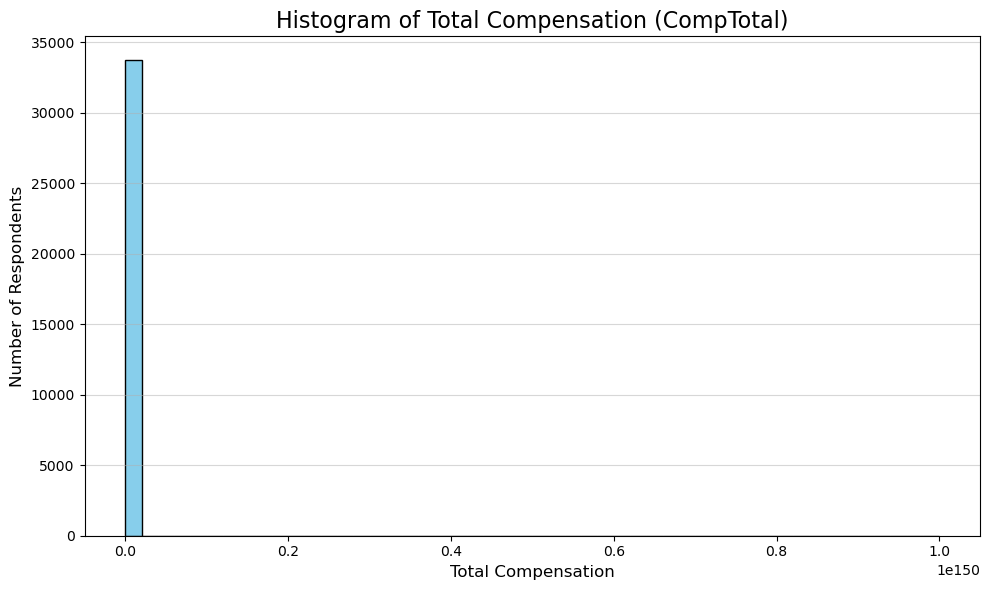

In [31]:
## Write your code here
conn = sqlite3.connect('survey-data.sqlite')

Query= """
Select CompTotal
FROM main
"""

comp_total_df=pd.read_sql_query(Query,conn)

conn.close()

plt.figure(figsize=(10, 6))
plt.hist(comp_total_df['CompTotal'], bins=50, color='skyblue', edgecolor='black')

plt.title("Histogram of Total Compensation (CompTotal)", fontsize=16)
plt.xlabel("Total Compensation", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()


**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


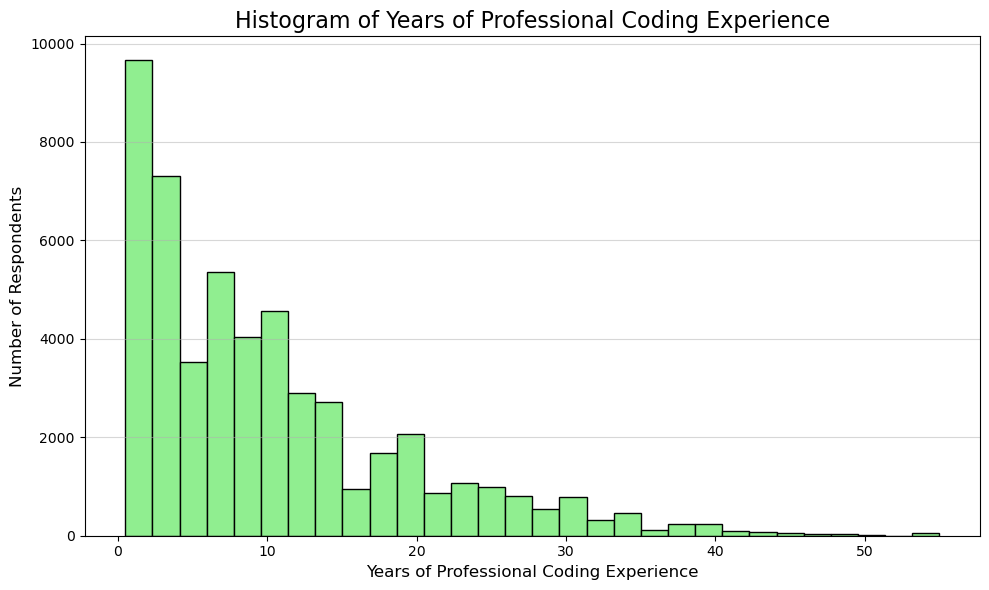

In [35]:
## Write your code here

conn=sqlite3.connect('survey-data.sqlite')

Query="""
Select YearsCodePro
from main
"""
df=pd.read_sql_query(Query,conn)
conn.close()

df = df.dropna(subset=['YearsCodePro'])

def convert_years(x):
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 55
    else:
        try:
            return float(x)
        except:
            return None

df['YearsCodeProNum'] = df['YearsCodePro'].apply(convert_years)
df = df.dropna(subset=['YearsCodeProNum'])

plt.figure(figsize=(10, 6))
plt.hist(df['YearsCodeProNum'], bins=30, color='lightgreen', edgecolor='black')

plt.title("Histogram of Years of Professional Coding Experience", fontsize=16)
plt.xlabel("Years of Professional Coding Experience", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [58]:
df

,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [62]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("survey-data.sqlite")
df_check = pd.read_sql_query("SELECT * FROM main LIMIT 5", conn)
conn.close()

print("Columns in table:", df_check.columns.tolist())
df_check.head()

Columns in table: ['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsy

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,None,None
3,4,I am learning to code,18-24 years old,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,None,None
4,5,I am a developer by profession,18-24 years old,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,None,None


In [68]:
# Connect to SQLite
conn = sqlite3.connect('survey-data.sqlite')

# Query only non-null CompTotal
QUERY = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
conn.close()

# Strip whitespace from column names (if any)
df.columns = df.columns.str.strip()

# Drop missing Age values just in case
df = df.dropna(subset=['Age'])

# Optional: Convert CompTotal to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

# Display first rows to verify
print(df.head())



   CompTotal              Age
0  2040000.0  18-24 years old
1    28000.0  25-34 years old
2    85000.0  35-44 years old
3    50000.0  35-44 years old
4   110000.0  25-34 years old


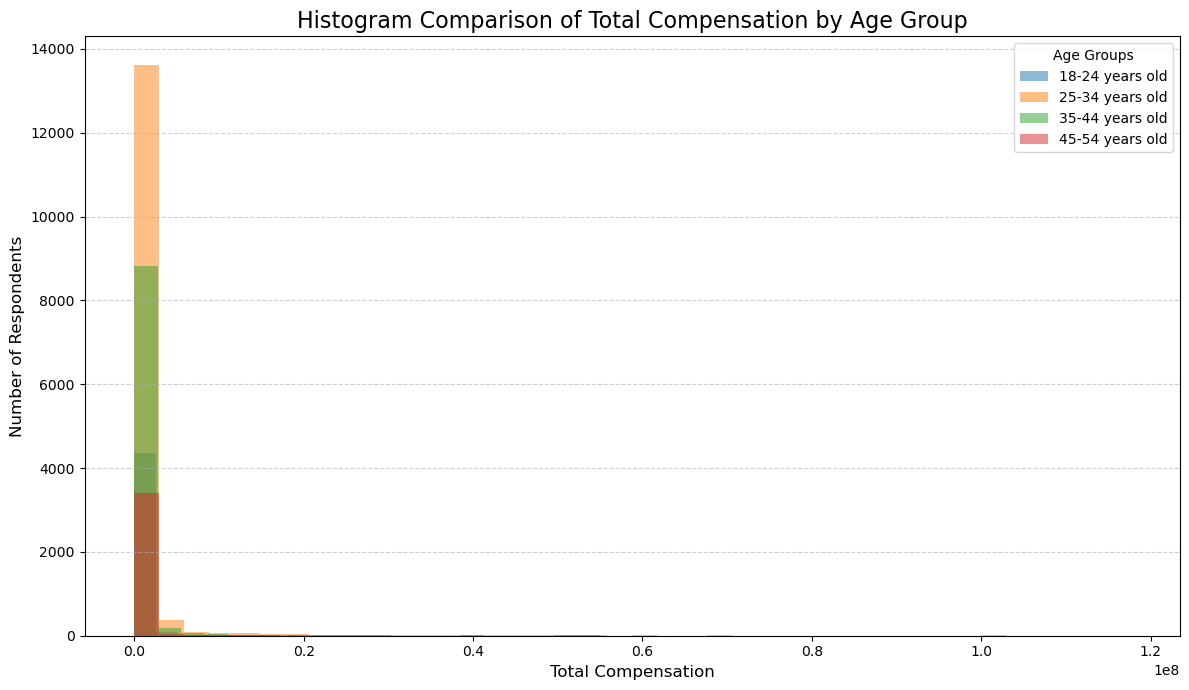

In [76]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to SQLite and load data
conn = sqlite3.connect('survey-data.sqlite')
QUERY = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
conn.close()

# 2. Clean column names
df.columns = df.columns.str.strip()

# 3. Drop rows with missing Age
df = df.dropna(subset=['Age'])

# 4. Convert CompTotal to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

# 5. Remove extreme outliers (optional, top 1%)
df = df[df['CompTotal'] < df['CompTotal'].quantile(0.99)]

# 6. Choose Age groups to compare
age_groups = [
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old'
]

# 7. Plot overlapping histograms
plt.figure(figsize=(12, 7))

for age in age_groups:
    subset = df[df['Age'] == age]['CompTotal']
    plt.hist(subset, bins=40, alpha=0.5, label=age)

plt.title("Histogram Comparison of Total Compensation by Age Group", fontsize=16)
plt.xlabel("Total Compensation", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.legend(title="Age Groups")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [ ]:
## Write your code here

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


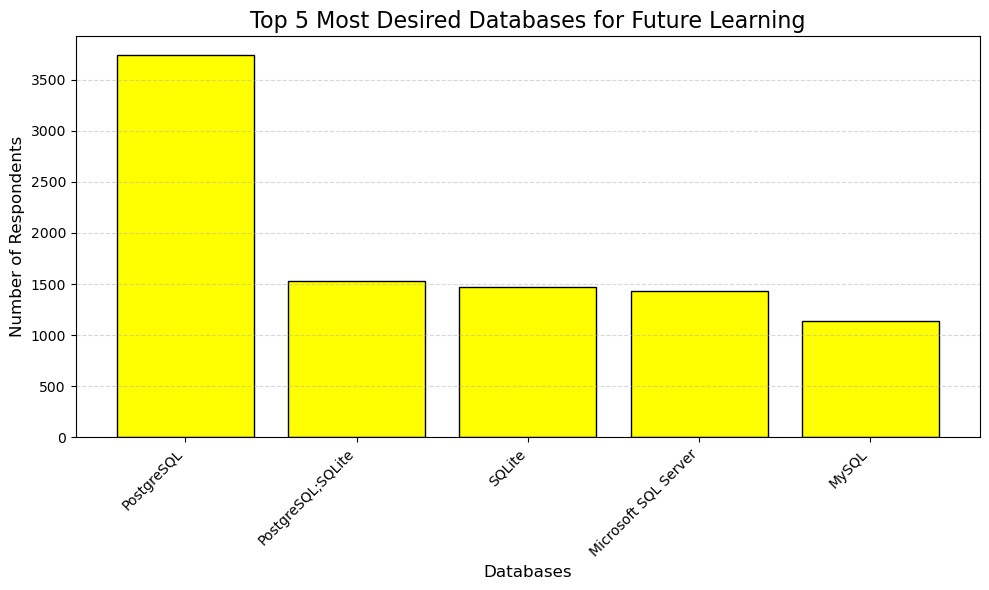

In [90]:
## Write your code here


# 1. Connect to SQLite and load data
conn = sqlite3.connect("survey-data.sqlite")
QUERY = "SELECT DatabaseWantToWorkWith FROM main"
df = pd.read_sql_query(QUERY, conn)
conn.close()

# 2. Drop missing values
df = df.dropna(subset=['DatabaseWantToWorkWith'])

# 3. Count the occurrences of each database
top5 = df['DatabaseWantToWorkWith'].value_counts().nlargest(5)

# 4. Plot bar chart (histogram-like)
plt.figure(figsize=(10, 6))
plt.bar(top5.index, top5.values, color='Yellow', edgecolor='black')

plt.title("Top 5 Most Desired Databases for Future Learning", fontsize=16)
plt.xlabel("Databases", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


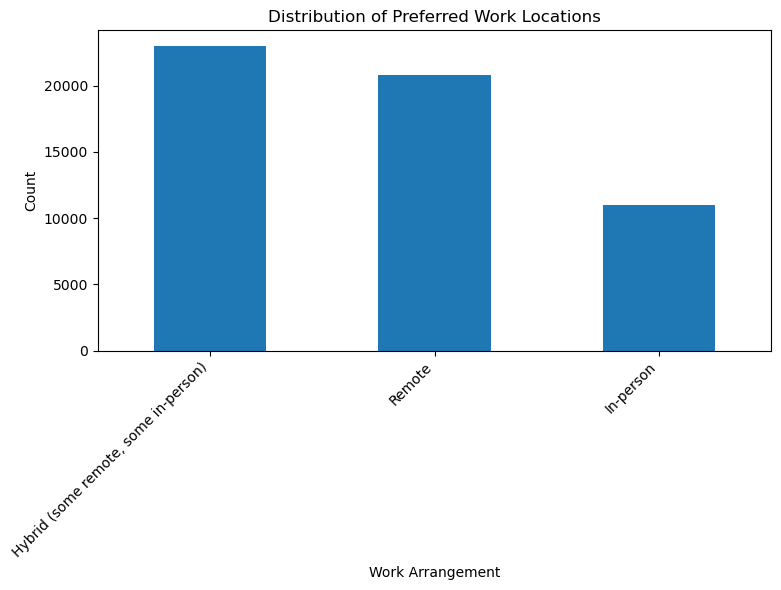

In [92]:
## Write your code here
conn = sqlite3.connect('survey-data.sqlite')

# Query the RemoteWork column
QUERY = """
SELECT RemoteWork
FROM main
"""
df = pd.read_sql_query(QUERY, conn)

# Close the connection
conn.close()

# Count the occurrences of each unique value in RemoteWork
remote_work_counts = df['RemoteWork'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 6))
remote_work_counts.plot(kind='bar')
plt.title('Distribution of Preferred Work Locations')
plt.xlabel('Work Arrangement')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


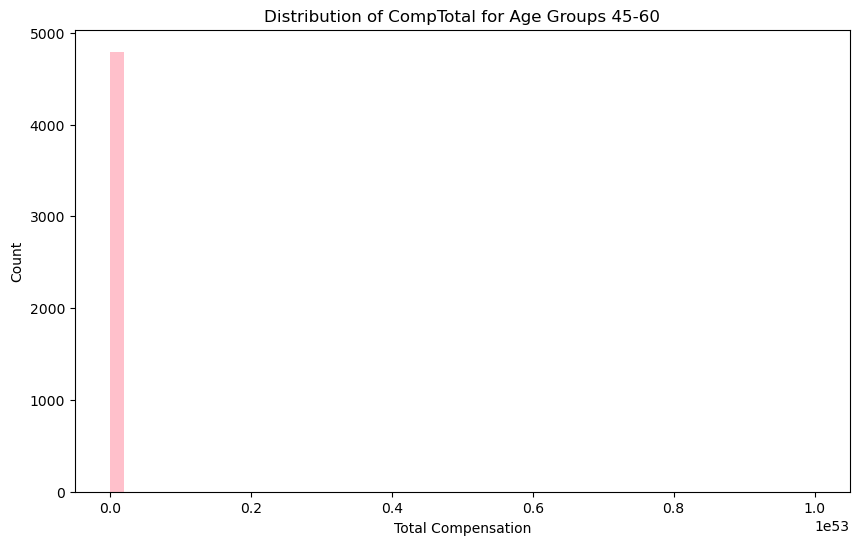

In [98]:
## Write your code here

conn = sqlite3.connect('survey-data.sqlite')

# Query the CompTotal and Age columns
QUERY = """
SELECT CompTotal, Age
FROM main
"""
df = pd.read_sql_query(QUERY, conn)

# Close the connection
conn.close()

# Filter the DataFrame for the age groups that cover 45 to 60
age_groups = ['45-54 years old', '55-64 years old']
filtered_age_df = df[df['Age'].isin(age_groups)].copy()

# Plot a histogram of the 'CompTotal' column for the filtered data
plt.figure(figsize=(10, 6))
plt.hist(filtered_age_df['CompTotal'].dropna(), bins=50,color='pink') # Use dropna() to handle missing values

# Add a title to the histogram
plt.title('Distribution of CompTotal for Age Groups 45-60')

# Label the x-axis
plt.xlabel('Total Compensation')

# Label the y-axis
plt.ylabel('Count')

# Display the histogram
plt.show()



**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


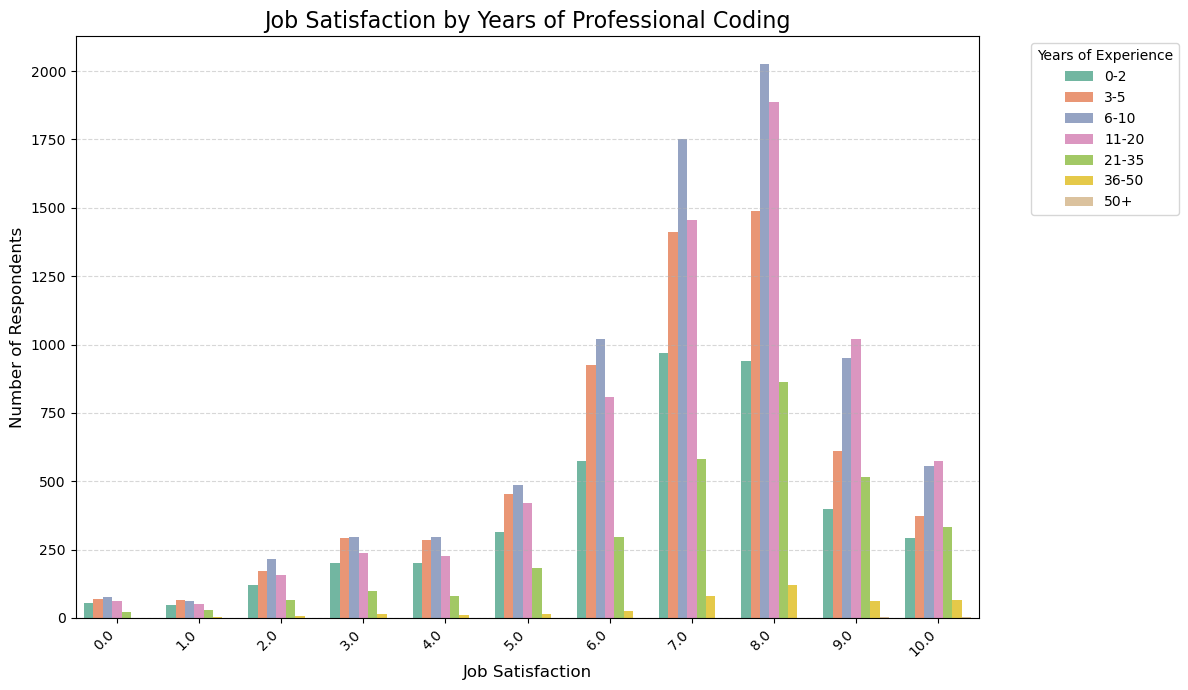

In [112]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connect to SQLite and load data
conn = sqlite3.connect("survey-data.sqlite")
QUERY = "SELECT JobSat, YearsCodePro FROM main"
df = pd.read_sql_query(QUERY, conn)
conn.close()

# 2. Drop missing values
df = df.dropna(subset=['JobSat', 'YearsCodePro'])

# 3. Convert YearsCodePro to numeric
def convert_years(x):
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 55
    else:
        try:
            return float(x)
        except:
            return None

df['YearsCodeProNum'] = df['YearsCodePro'].apply(convert_years)
df = df.dropna(subset=['YearsCodeProNum'])

# 4. Bin YearsCodePro for better visualization
bins = [0, 2, 5, 10, 20, 35, 50, 60]
labels = ['0-2', '3-5', '6-10', '11-20', '21-35', '36-50', '50+']
df['YearsBin'] = pd.cut(df['YearsCodeProNum'], bins=bins, labels=labels, include_lowest=True)

# 5. Plot countplot (histogram-like) using Seaborn
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df,
    x='JobSat',
    hue='YearsBin',
    palette='Set2',
    order=df['JobSat'].astype('category').cat.categories  # preserves original order
)

plt.title("Job Satisfaction by Years of Professional Coding", fontsize=16)
plt.xlabel("Job Satisfaction", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Years of Experience", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
